In [ ]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

#print("Path to dataset files:", path)

c:\Projects\python_and_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 66.0M/66.0M [00:02<00:00, 25.2MB/s]

Extracting files...


Path to dataset files: C:\Users\peter\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


EDA Analys

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-stil
sns.set(style="whitegrid", context="notebook")

# Ladda data
df = pd.read_csv("creditcard.csv")

In [4]:

print("Shape:", df.shape)
print("\nKolumner:")
print(df.columns.tolist())

print("\nDatatyper:")
print(df.dtypes)

print("\nSaknade värden totalt:", df.isnull().sum().sum())


Shape: (284807, 31)

Kolumner:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Datatyper:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Saknade värden totalt: 0


In [15]:
class_counts = df["Class"].value_counts()
class_ratio = df["Class"].value_counts(normalize=True)

print(class_counts.index)
print(class_counts.values)

print("Antal per klass:")
print(class_counts)


print("\nAndel per klass:")
print(class_ratio)



Index([0, 1], dtype='int64', name='Class')
[284315    492]
Antal per klass:
Class
0    284315
1       492
Name: count, dtype: int64

Andel per klass:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


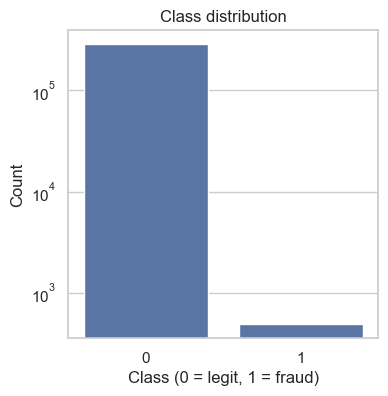

In [22]:

plt.figure(figsize=(4,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution")
plt.xlabel("Class (0 = legit, 1 = fraud)")
plt.ylabel("Count")
plt.yscale("log")  # log-skala p.g.a. extrem obalans
plt.show()


In [16]:
print(df["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


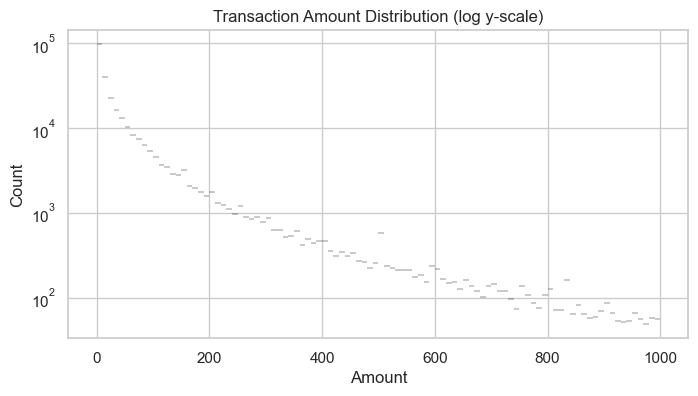

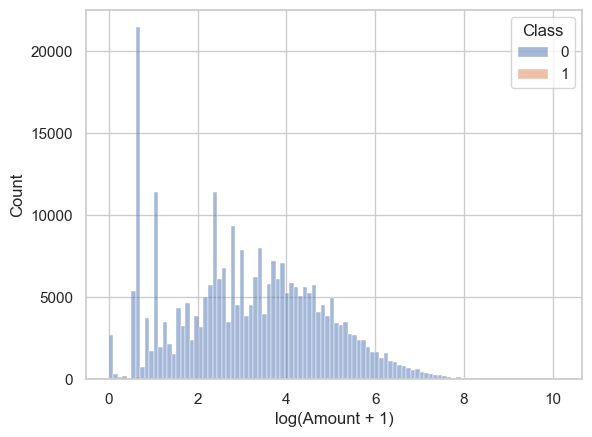

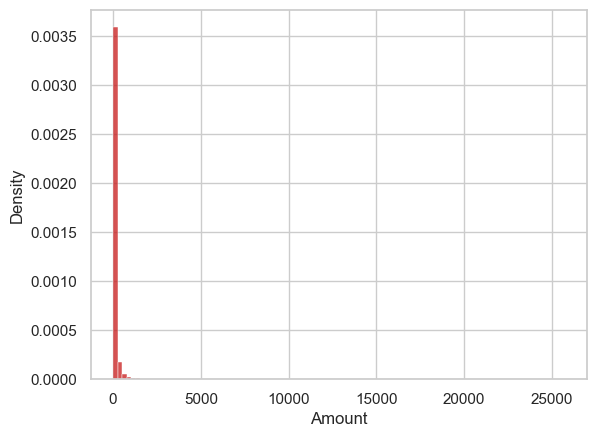

In [43]:

plt.figure(figsize=(8,4))

sns.histplot(
    df[df["Amount"] < 1000]["Amount"], #Zoom in on those less than 1000
    bins=100,
    log_scale=(False, True),
    color="#C71A1A",
    alpha=1.0,
    edgecolor="black",
    linewidth=0.3
)

plt.title("Transaction Amount Distribution (log y-scale)")
plt.xlabel("Amount")
plt.show()


df["Amount_log"] = np.log1p(df["Amount"])

sns.histplot(
    
    data=df,
    x="Amount_log",
    hue="Class",
    bins=100
)
plt.xlabel("log(Amount + 1)")
plt.show()

sns.histplot(
    df["Amount"],
    bins=100,
    stat="density",
    log_scale=(False, False),
    color="#C71A1A"
)

plt.show()

In [31]:
print(df["Time"].describe())

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


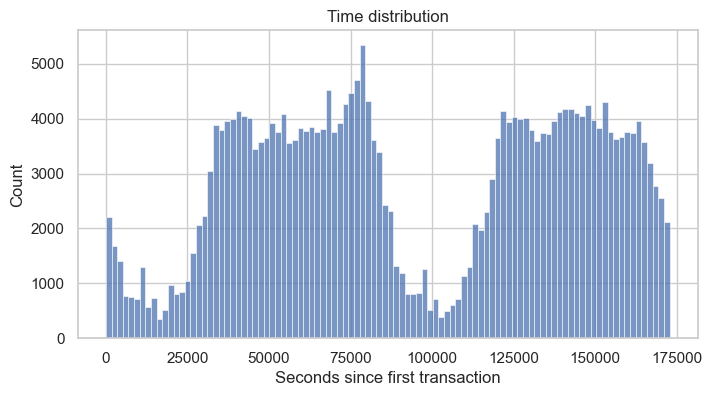

In [32]:

plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=100)
plt.title("Time distribution")
plt.xlabel("Seconds since first transaction")
plt.show()


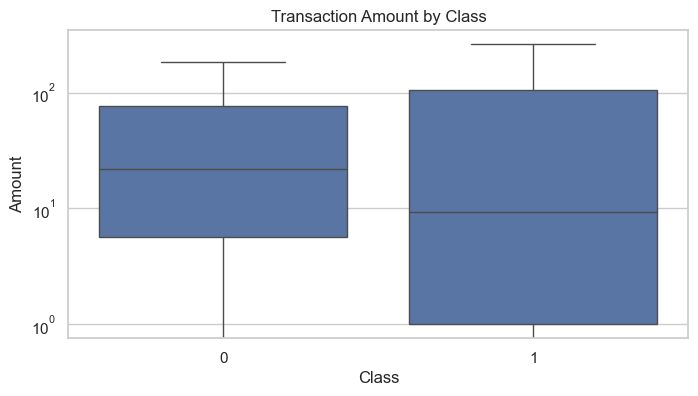

In [23]:

plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df, showfliers=False)
plt.title("Transaction Amount by Class")
plt.yscale("log")
plt.show()


In [33]:

corr = (
    df.corr(numeric_only=True)["Class"]
    .abs()
    .sort_values(ascending=False)
)

top_corr = corr.drop("Class").head(10)

print("Top 10 features korrelerade med Class:")
print(top_corr)


Top 10 features korrelerade med Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


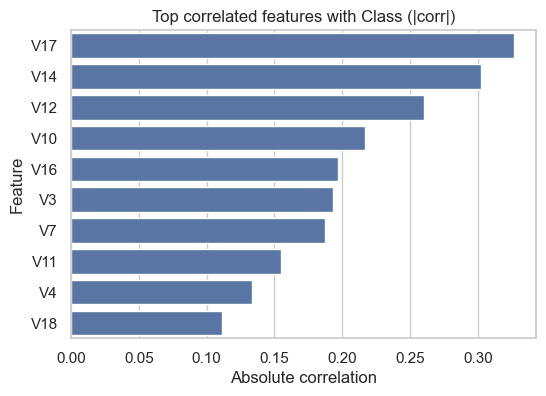

In [34]:

plt.figure(figsize=(6,4))
sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    orient="h"
)
plt.title("Top correlated features with Class (|corr|)")
plt.xlabel("Absolute correlation")
plt.ylabel("Feature")
plt.show()


In [40]:

summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "fraud_ratio": class_ratio[1],
    "amount_median": df["Amount"].median(),
    "amount_max": df["Amount"].max(),
}

print(summary)


{'rows': 284807, 'columns': 32, 'fraud_ratio': np.float64(0.001727485630620034), 'amount_median': np.float64(22.0), 'amount_max': np.float64(25691.16)}


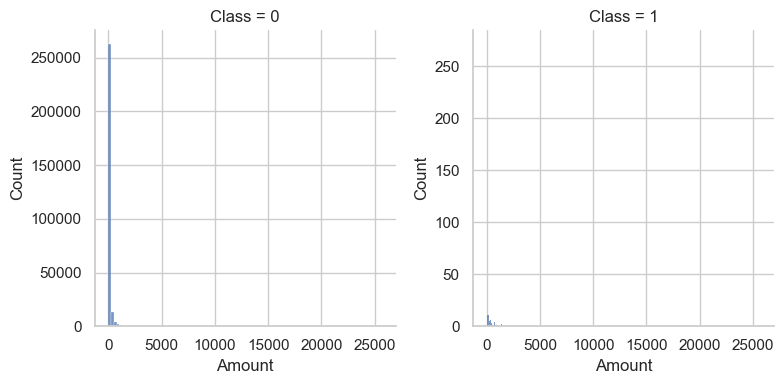

In [44]:
g = sns.FacetGrid(
    df,
    col="Class",
    sharey=False,
    height=4
)
g.map_dataframe(
    sns.histplot,
    x="Amount",
    bins=100
)


<Axes: xlabel='Amount', ylabel='Count'>

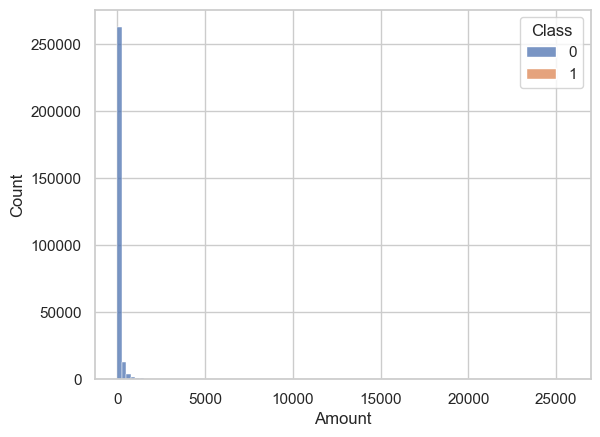

In [45]:
sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    multiple="stack"
)

In [41]:
print(df.info())

print(df.head())

print(df.tail())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Time        284807 non-null  float64
 1   V1          284807 non-null  float64
 2   V2          284807 non-null  float64
 3   V3          284807 non-null  float64
 4   V4          284807 non-null  float64
 5   V5          284807 non-null  float64
 6   V6          284807 non-null  float64
 7   V7          284807 non-null  float64
 8   V8          284807 non-null  float64
 9   V9          284807 non-null  float64
 10  V10         284807 non-null  float64
 11  V11         284807 non-null  float64
 12  V12         284807 non-null  float64
 13  V13         284807 non-null  float64
 14  V14         284807 non-null  float64
 15  V15         284807 non-null  float64
 16  V16         284807 non-null  float64
 17  V17         284807 non-null  float64
 18  V18         284807 non-null  float64
 19  V19         2

Setup för träning för att upptäcka fraud

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


In [49]:
# Load data
#df = pd.read_csv("creditcard.csv")

X = df.drop(columns=["Class"])
y = df["Class"]

# Stratified split (KRITISKT vid obalans)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#PCA‑features är redan “nästan” normaliserade,
#men Logistic Regression kräver ändå korrekt skalning.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_scaled, y_train)

y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = log_reg.predict(X_test_scaled)

(56962,)


In [66]:
print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("PR-AUC:", average_precision_score(y_test, y_proba_lr))
#We are calculating which transactions are Fraud
#Thus in binary classification, the count of 
# true negatives is C_{0,0}, TN - These are correct transactions and we predicted that with our model (55483)
# false negatives is C_{1,0}, FN - The model said that this was a correct transaction when it in fact was Fraud (8)
# true positives is C_{1,1}, TP - Fraud transactions that we cought (90)
# false positives is C_{0,1}. FP - We identified correct transactions as fraud (1381)
cm = confusion_matrix(y_test, y_pred_lr)
print(f'CM={cm}')
print(classification_report(y_test, y_pred_lr, digits=4))

TN, FP, FN, TP = cm.ravel()

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")


Logistic Regression
ROC-AUC: 0.9718520128225742
PR-AUC: 0.7194303169083883
CM=[[55483  1381]
 [    8    90]]
              precision    recall  f1-score   support

           0     0.9999    0.9757    0.9876     56864
           1     0.0612    0.9184    0.1147        98

    accuracy                         0.9756     56962
   macro avg     0.5305    0.9470    0.5512     56962
weighted avg     0.9982    0.9756    0.9861     56962

True Positives (TP): 90
False Positives (FP): 1381
True Negatives (TN): 55483
False Negatives (FN): 8


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

In [61]:
print("Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
ROC-AUC: 0.9470193113824033
PR-AUC: 0.8672235547805649
[[56861     3]
 [   22    76]]


In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_proba_gb = gb.predict_proba(X_test)[:, 1]
y_pred_gb = gb.predict(X_test)

In [ ]:
print("Gradient Boosting")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))
print("PR-AUC:", average_precision_score(y_test, y_proba_gb))
print(confusion_matrix(y_test, y_pred_gb))



Gradient Boosting
ROC-AUC: 0.3468859283302516
PR-AUC: 0.15665434666029338
[[56848    16]
 [   80    18]]


In [62]:
results = pd.DataFrame({
    "Model": ["LogReg", "RandomForest", "GradientBoosting"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_gb)
    ]
})

results


,Model,ROC_AUC,PR_AUC
0,LogReg,0.971852,0.719430
1,RandomForest,0.947019,0.867224
2,GradientBoosting,0.346886,0.156654


In [64]:
#Recall, Precision, False positive rate, false negative rate
recall = TP / (TP + FN)
precision = TP / (TP + FP)
fpr = FP / (FP + TN) #False positives rate, dvs. hur många kunder anklagas för fraud som inte har gjort något
fnr = FN / (FN + TP) #False negative rate, dvs. hur många frauds missar vi

print(f"Recall (TPR): {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"False Positive Rate: {fpr:.5f}")
print(f"False Negative Rate: {fnr:.3f}")

Recall (TPR): 0.918
Precision: 0.061
False Positive Rate: 0.02429
False Negative Rate: 0.082


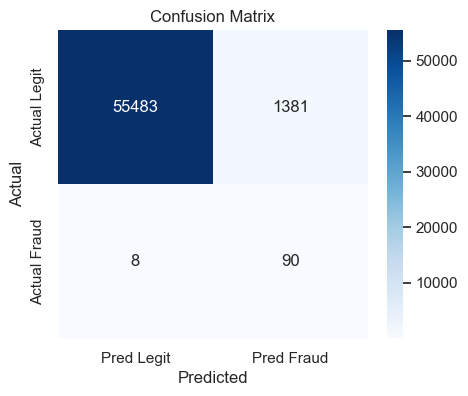

In [65]:
#Visualisera confusion matrix med en heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Legit", "Pred Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"]
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

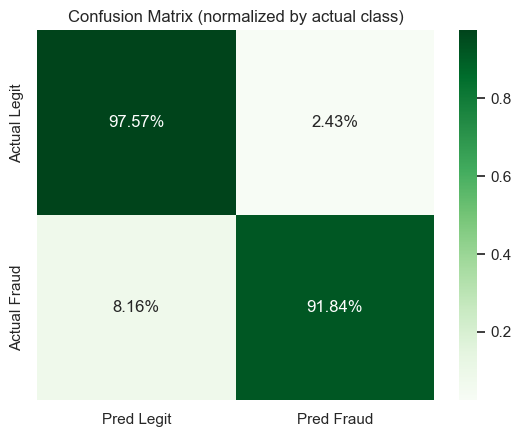

In [67]:
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=["Pred Legit", "Pred Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"]
)
plt.title("Confusion Matrix (normalized by actual class)")
plt.show()